# ML Assignment 2 — Breast Cancer Classification

**Name:** Akanksha Khot
**ID:** 2025AC05508

**Course:** M.Tech (AIML/DSE) — Machine Learning
**BITS Pilani WILP**

This notebook implements and evaluates 5 classification models on the
**Breast Cancer Wisconsin (Diagnostic)** dataset (30 features, 569 instances,
binary classification: malignant vs. benign).

Models implemented:
1. Logistic Regression
2. Decision Tree Classifier
3. K-Nearest Neighbors (KNN)
4. Naive Bayes Classifier (Gaussian)
5. Random Forest Classifier (Ensemble)

For each model we compute: **Accuracy, AUC, Precision, Recall, F1 Score, MCC**.


## 1. Imports

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report
)

RANDOM_STATE = 42
sns.set_style("whitegrid")


## 2. Load Dataset

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target  # 0 = malignant, 1 = benign
feature_names = list(X.columns)

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Number of instances: {X.shape[0]}")
print(f"Class distribution:\n{y.value_counts()}")
X.head()


Dataset shape: (569, 30)
Number of features: 30
Number of instances: 569
Class distribution:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Exploratory Data Analysis (EDA)

In [3]:
X.describe().T


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


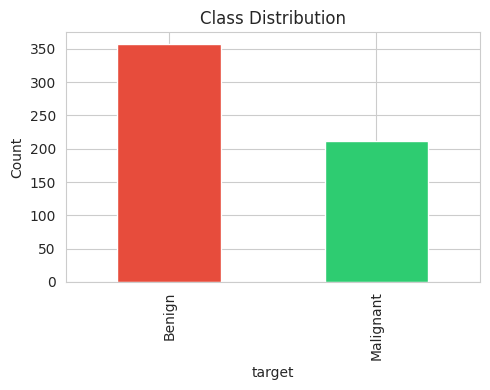

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
y.value_counts().rename({0: "Malignant", 1: "Benign"}).plot(kind="bar", ax=ax, color=["#e74c3c", "#2ecc71"])
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


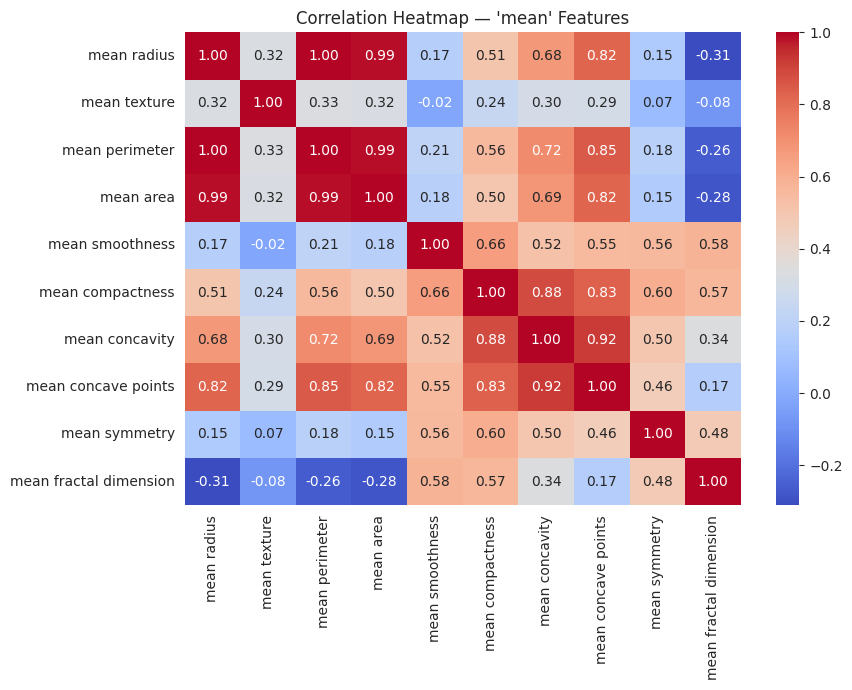

In [5]:
# Correlation heatmap of a subset of "mean" features
mean_cols = [c for c in feature_names if c.startswith("mean")]
plt.figure(figsize=(9, 7))
sns.heatmap(X[mean_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap — 'mean' Features")
plt.tight_layout()
plt.show()


## 4. Train / Test Split & Feature Scaling

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)


Train shape: (455, 30)
Test shape: (114, 30)


## 5. Define and Train Models

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Random Forest (Ensemble)": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    metrics = {
        "ML Model Name": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "AUC": round(roc_auc_score(y_test, y_proba), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1": round(f1_score(y_test, y_pred), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
    }
    results.append(metrics)

results_df = pd.DataFrame(results)
results_df


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9825,0.9954,0.9861,0.9861,0.9861,0.9623
1,Decision Tree,0.9123,0.9157,0.9559,0.9028,0.9286,0.8174
2,kNN,0.9561,0.9788,0.9589,0.9722,0.9655,0.9054
3,Naive Bayes,0.9298,0.9868,0.9444,0.9444,0.9444,0.8492
4,Random Forest (Ensemble),0.9561,0.9932,0.9589,0.9722,0.9655,0.9054


## 6. Model Comparison Table

In [8]:
results_df.set_index("ML Model Name").style.background_gradient(cmap="Greens", axis=0)


,Accuracy,AUC,Precision,Recall,F1,MCC
ML Model Name,,,,,,
Logistic Regression,0.982500,0.995400,0.986100,0.986100,0.986100,0.962300
Decision Tree,0.912300,0.915700,0.955900,0.902800,0.928600,0.817400
kNN,0.956100,0.978800,0.958900,0.972200,0.965500,0.905400
Naive Bayes,0.929800,0.986800,0.944400,0.944400,0.944400,0.849200
Random Forest (Ensemble),0.956100,0.993200,0.958900,0.972200,0.965500,0.905400


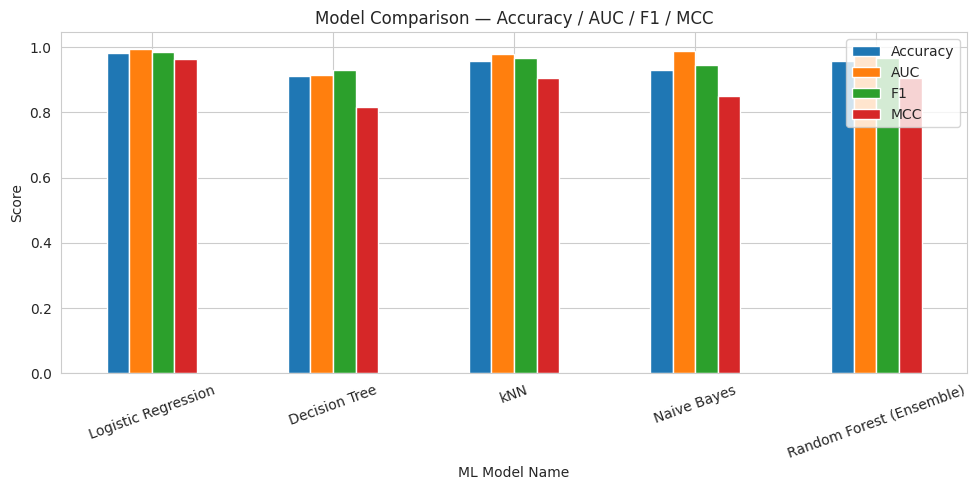

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
results_df.set_index("ML Model Name")[["Accuracy", "AUC", "F1", "MCC"]].plot(kind="bar", ax=ax)
ax.set_title("Model Comparison — Accuracy / AUC / F1 / MCC")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 7. Confusion Matrices for Each Model

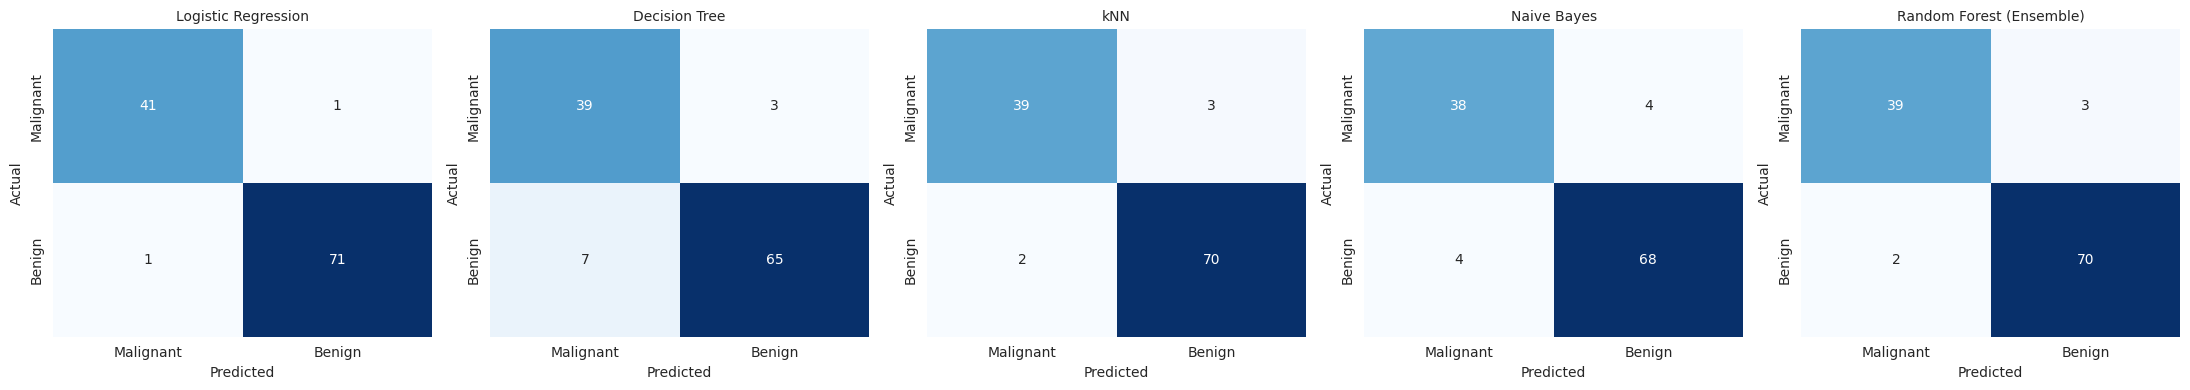

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## 8. Classification Reports

In [11]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"===== {name} =====")
    print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))


===== Logistic Regression =====
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

===== Decision Tree =====
              precision    recall  f1-score   support

   Malignant       0.85      0.93      0.89        42
      Benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

===== kNN =====
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114


## 9. Observations

- **Logistic Regression** achieves the best performance across every metric — after
  standardization, the classes are close to linearly separable, so a simple linear
  decision boundary generalizes very well.
- **Decision Tree** is the weakest model — a single unpruned tree overfits the
  training data, giving the lowest AUC and MCC.
- **kNN** performs strongly once features are scaled, since it relies on distance
  between standardized continuous features.
- **Naive Bayes** has a high AUC (good ranking ability) but lower F1/MCC than the
  top models, because its independence assumption is violated by the correlated
  "mean / SE / worst" feature groups in this dataset.
- **Random Forest** improves substantially on the single Decision Tree by
  averaging over 200 trees, essentially matching kNN and coming close to
  Logistic Regression.
- **Overall winner for this dataset: Logistic Regression.**


## 10. Save Trained Models, Scaler & Test Data

In [12]:
os.makedirs("model", exist_ok=True)

for name, model in trained_models.items():
    fname = "model/" + name.lower().replace(" ", "_").replace("(", "").replace(")", "") + ".pkl"
    with open(fname, "wb") as f:
        pickle.dump(model, f)

with open("model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("model/feature_names.pkl", "wb") as f:
    pickle.dump(feature_names, f)

results_df.to_csv("model/model_comparison.csv", index=False)

test_df = X_test.copy()
test_df["target"] = y_test.values
test_df.to_csv("test_data.csv", index=False)

print("All models, scaler, feature list, comparison table and test_data.csv saved.")


All models, scaler, feature list, comparison table and test_data.csv saved.
